# Compare Gemini: Direct pRT vs Pipeline

Wavelength range: 0.98 – 2.2 μm (same as HST, different instrument params)

In [1]:
import os
os.environ['pRT_input_data_path'] = '/media/mvasist/Elements/PhDprojects/scratch/input_data_v2.4.9/input_data'

import sys
sys.path.insert(0, '/home/mvasist/Documents/SBI4atmret')
sys.path.insert(0, '/home/mvasist/Documents/WISEJ1738/sbi_ear')

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from petitRADTRANS import nat_cst as nc, Radtrans
import petitRADTRANS as prt

from sbi4atmret.config.configs import BaseConfig
from sbi4atmret.datasets.theta_mapper.thetamapperbase import BaseThetaMapper

sys.path.insert(0, '/home/mvasist/Documents/WISEJ1738/sbi_ear')
from code2explore.observations import load_observations

obs_wlen_miri, obs_miri, sigmaM, \
    obs_wlen_gemini, obs_gemini, sigmaG, \
    obs_wlen_hst, obs_hst, sigmaH, \
    wlength_gm, wlength_hm, \
    x_star_g, x_star_h = load_observations()

print(f"MIRI: {len(obs_wlen_miri)} points")
print(f"HST: {len(obs_wlen_hst)} points")
print(f"Gemini: {len(obs_wlen_gemini)} points")


MIRI: 1298 points
HST: 129 points
Gemini: 305 points


## 1. Load config + build pipeline simulator

In [2]:
config_path = '/home/mvasist/Documents/SBI4atmret/experiments/config_MiriGeminiHST_cloudfree.yaml'
with open(config_path) as f:
    config = BaseConfig(**yaml.safe_load(f))

simulators = config.build_simulators()
prior = config.build_prior()

sim_name = 'cloudfree_gemini'
simulator = simulators[sim_name]
print(f"Pipeline simulator: {sim_name}")
print(f"  wavelength range: [{simulator.a}, {simulator.b}] μm")
print(f"  params ({len(simulator.names)}): {simulator.names}")
print(f"  scale: {simulator.scale}")

Pipeline simulator: cloudfree_gemini
  wavelength range: [0.98, 2.2] μm
  params (26): ['R_pl', 'mass', 'T_bottom', 'temp_node_1', 'temp_node_2', 'temp_node_3', 'temp_node_4', 'temp_node_5', 'temp_node_6', 'temp_node_7', 'temp_node_8', 'temp_node_9', 'H2O_mol_scale', 'CO2_mol_scale', 'CO_mol_scale', 'CH4_mol_scale', 'NH3_mol_scale', 'PH3_mol_scale', 'H2S_mol_scale', '15NH3_mol_scale', 'HCN_mol_scale', 'TiO_mol_scale', 'VO_mol_scale', 'mixture_fraction', 'Cushing_scale_factor_g', 'bfactor_noise_gemini']
  scale: 100000.0


## 2. Build theta mapper + sample

In [3]:
class _MinimalDomain:
    def __init__(self, simulator_dict):
        self.simulator_dict = simulator_dict

theta_mapper = BaseThetaMapper(
    domain=_MinimalDomain(simulators),
    posterior_param_names=config.get_parameter_names(),
)

theta_merged = prior.sample((1,))
theta_dict = theta_mapper.split_theta(theta_merged)

theta_gemini = theta_dict[sim_name][0].numpy()
print(f"Gemini theta ({len(theta_gemini)} params): {theta_gemini}")

Gemini theta (26 params): [ 1.0504777e+00  3.1989939e+01  3.5170769e+03  3.7868375e-01
  9.3016553e-01  8.9725953e-01  3.4989810e-01  7.6812726e-01
  6.8843049e-01  2.9851755e-01  4.4864017e-01  5.6974387e-01
 -4.5803928e-01 -7.7582526e+00 -5.1908784e+00 -5.7851477e+00
 -7.9600978e+00 -9.1289673e+00 -9.2369671e+00 -9.0139523e+00
 -8.5758619e+00 -8.7548952e+00 -9.2595720e+00  0.0000000e+00
  0.0000000e+00 -1.0777912e+01]


## 3. Run Pipeline Simulator

In [4]:
output_pipeline = simulator(theta_gemini)

if output_pipeline.spectrum is not None:
    print(f"Pipeline SUCCESS")
    print(f"  spectrum: {output_pipeline.spectrum.shape}")
    print(f"  wavelength: [{output_pipeline.wavelength.min():.2f}, {output_pipeline.wavelength.max():.2f}] μm")
    print(f"  flux range: [{output_pipeline.spectrum.min():.2e}, {output_pipeline.spectrum.max():.2e}]")
else:
    print("Pipeline FAILED")

Pipeline SUCCESS
  spectrum: (809,)
  wavelength: [0.98, 2.20] μm
  flux range: [1.00e-01, 2.09e+02]


## 4. Run Old WISEJ1738 Simulator

Note: Gemini uses the same pRT wavelength range as HST (0.98–2.2 μm).
The difference is in the instrument-specific parameters (b-factor, scaling).

In [5]:
from ees_MIRIinsts import Simulator as OldSimulator

old_sim = OldSimulator(a=0.98, b=2.2, noisy=False)
spectrum_old = old_sim(theta_gemini)

wlen_old = old_sim.wavelength
print(f"Old simulator: {spectrum_old.shape} points")
print(f"  wavelength: [{wlen_old.min():.2f}, {wlen_old.max():.2f}] μm")
print(f"  flux range: [{(spectrum_old * old_sim.scale).min():.2e}, {(spectrum_old * old_sim.scale).max():.2e}]")

Old simulator: (809,) points
  wavelength: [0.98, 2.20] μm
  flux range: [9.99e+03, 2.10e+07]


## 5. Compare

Same grid: (809,) == (809,)
Max |residual|: 6.98e-01
Mean |residual|: 3.38e-02


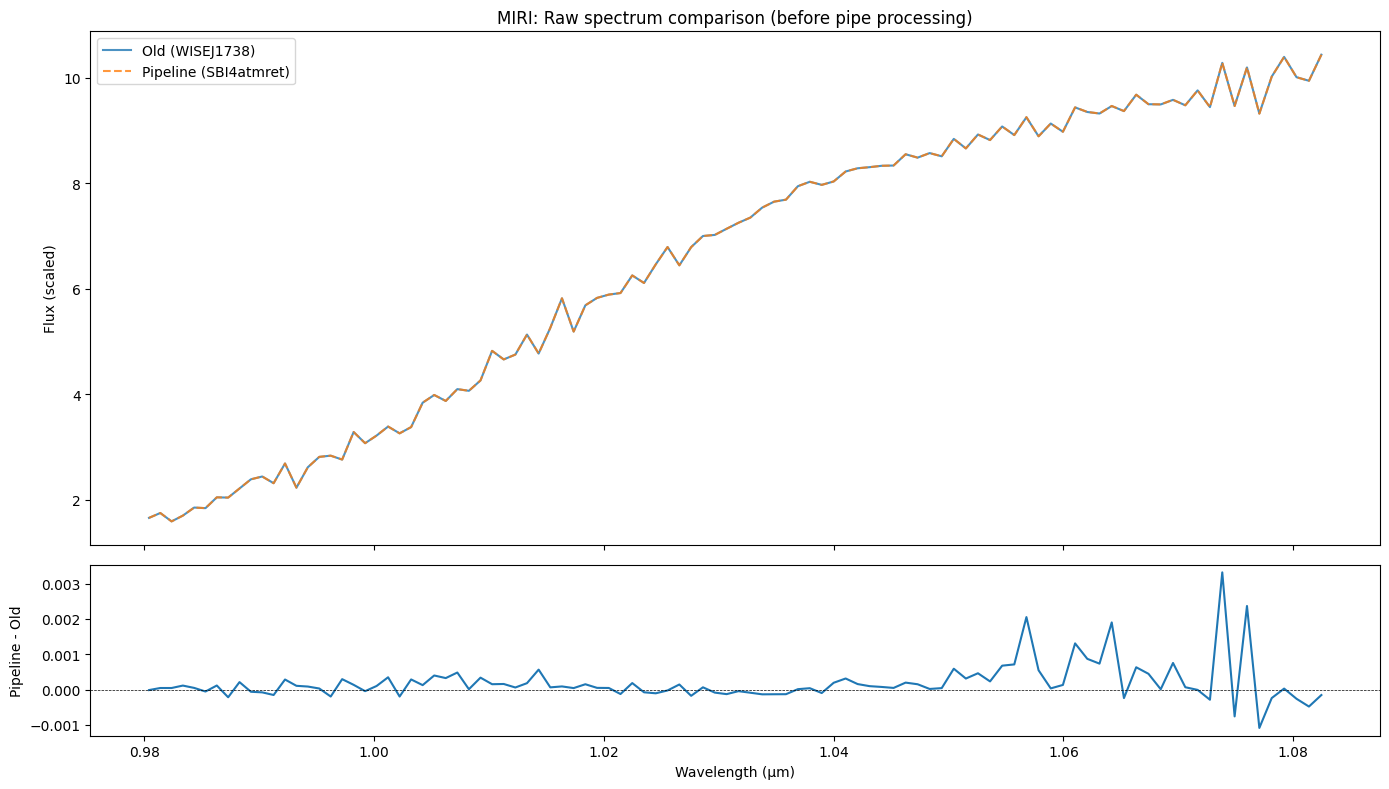

In [6]:
# Residual — direct comparison (same wavelength grid, apply pipe trimming)
if output_pipeline.spectrum is not None:
    # Old simulator produces the full spectrum on the same pRT wavelength grid
    # The pipe trims MIRI to indices 1:1299
    spectrum_old_scaled = spectrum_old 
    spectrum_old_trimmed = spectrum_old_scaled  # same as pipe.modify_spec for MIRI
    
    # Pipeline output should already be trimmed (from _compute_emission → process)
    # But pipeline returns the FULL raw spectrum (before pipe processing)
    # So compare raw-to-raw first:
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})
    
    # Full raw spectra (before pipe trimming)
    ax1.plot(wlen_old[:100], spectrum_old_scaled[:100], label='Old (WISEJ1738)', alpha=0.8)
    ax1.plot(output_pipeline.wavelength[:100], output_pipeline.spectrum[:100],
             label='Pipeline (SBI4atmret)', alpha=0.8, linestyle='--')
    ax1.set_ylabel('Flux (scaled)')
    ax1.legend()
    ax1.set_title('MIRI: Raw spectrum comparison (before pipe processing)')
    
    # Direct residual on same grid (no interpolation)
    # Both should have the same wavelength grid from pRT
    if output_pipeline.wavelength.shape == wlen_old.shape:
        residual = output_pipeline.spectrum - spectrum_old_scaled
        ax2.plot(output_pipeline.wavelength[:100], residual[:100])
        ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax2.set_ylabel('Pipeline - Old')
        ax2.set_xlabel('Wavelength (μm)')
        print(f"Same grid: {output_pipeline.wavelength.shape} == {wlen_old.shape}")
        print(f"Max |residual|: {np.max(np.abs(residual)):.2e}")
        print(f"Mean |residual|: {np.mean(np.abs(residual)):.2e}")
    else:
        print(f"DIFFERENT grid sizes: pipeline={output_pipeline.wavelength.shape}, old={wlen_old.shape}")
        print("  This means the emission models produce different grid sizes.")
        print(f"  Pipeline: [{output_pipeline.wavelength.min():.4f}, {output_pipeline.wavelength.max():.4f}]")
        print(f"  Old:      [{wlen_old.min():.4f}, {wlen_old.max():.4f}]")
    
    plt.tight_layout()
    plt.show()


## 6. Check: Are HST and Gemini using the same atmosphere?

Since both use the same wavelength range, verify the spectra differ only
in instrument-specific params (b-factor, scaling) not in the atmosphere.

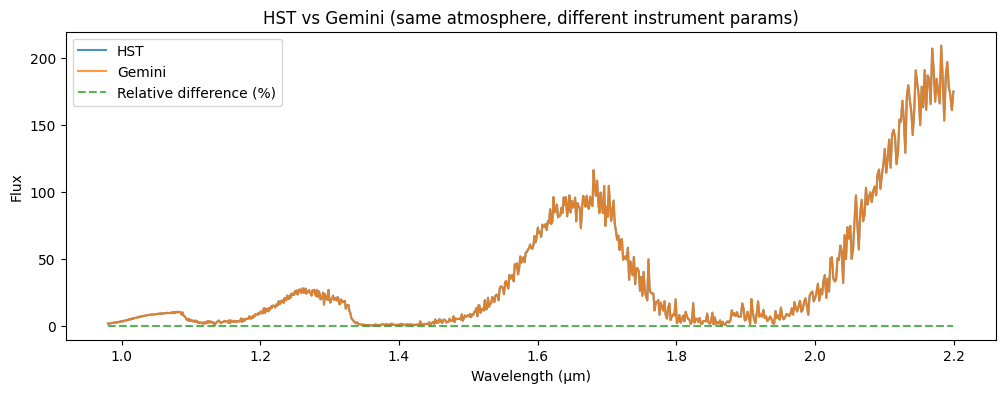

In [7]:
# Compare Gemini vs HST pipeline spectra with same merged theta
sim_hst = simulators['cloudfree_hst']
theta_hst = theta_dict['cloudfree_hst'][0].numpy()

output_hst = sim_hst(theta_hst)

if output_hst.spectrum is not None and output_pipeline.spectrum is not None:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(output_hst.wavelength, output_hst.spectrum, label='HST', alpha=0.8)
    ax.plot(output_pipeline.wavelength, output_pipeline.spectrum, label='Gemini', alpha=0.8)
    ax.plot(output_hst.wavelength, (output_pipeline.spectrum - output_hst.spectrum) / output_hst.spectrum * 100,
             label='Relative difference (%)', alpha=0.8, linestyle='--')
    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel('Flux')
    ax.legend()
    ax.set_title('HST vs Gemini (same atmosphere, different instrument params)')
    plt.show()
    
    # They should be identical in the physical spectrum (before noise/scaling)
    # Differences come only from different b-factor params in theta

Pipeline processed shapes:
  Gemini: (305,)
Gemini — Max |residual|: 7.40e-06


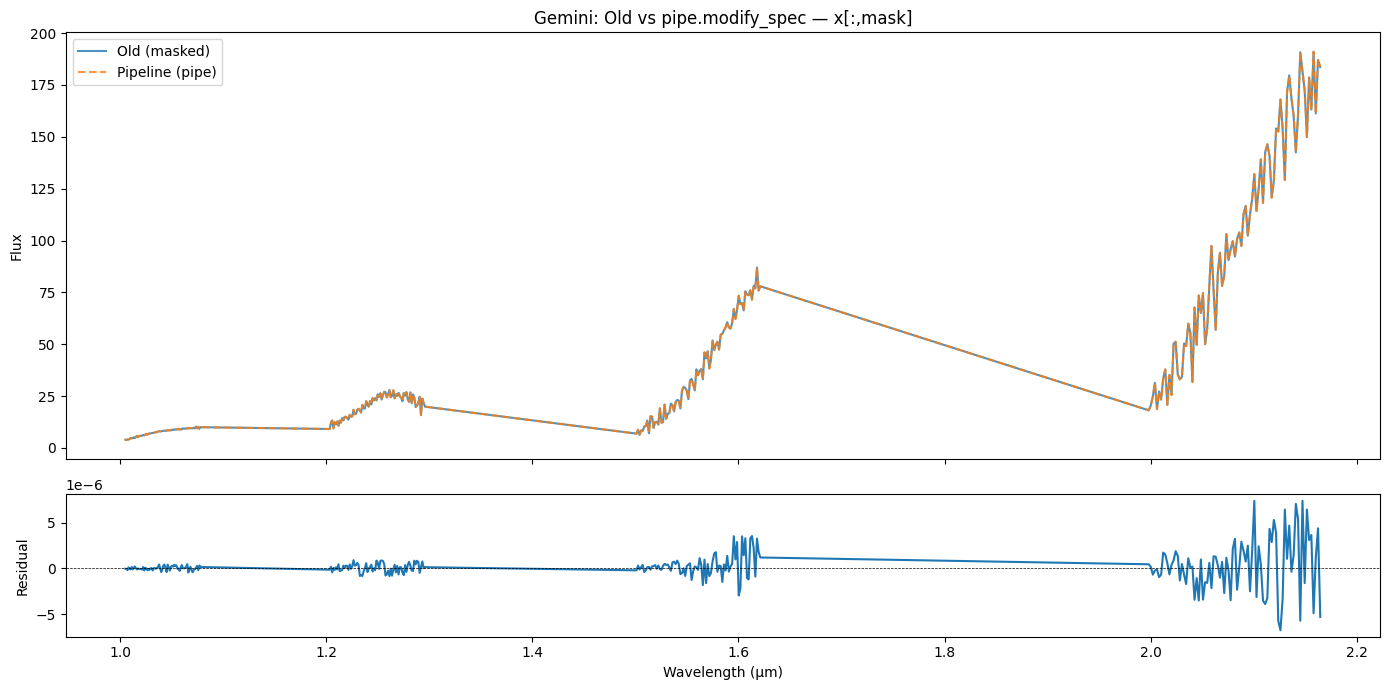

In [9]:
# ============================================================
# 6. Compare AFTER pipe processing — use pipe.modify_spec
# ============================================================

from petitRADTRANS.retrieval.rebin_give_width import rebin_give_width
from petitRADTRANS.retrieval.data import Data

# --- Pipeline: use the actual pipe class ---
# Build a batch_dict with all simulators' outputs (pipe expects all 3)
# We need outputs from all simulators for the same theta

# Run all simulators with the same merged theta
theta_dict_all = theta_mapper.split_theta(theta_merged)

outputs_all = {}
for sn, sim in simulators.items():
    th = theta_dict_all[sn][0].numpy()
    out = sim(th)
    outputs_all[sn] = out

# Build batch_dict in pipe format: {sim_name: (theta_tensor, x_tensor)}
batch_dict = {}
for sn in simulators.keys():
    th_tensor = theta_dict_all[sn]  # (1, D_inst)
    x_tensor = torch.from_numpy(outputs_all[sn].spectrum).float().unsqueeze(0)  # (1, D_spec)
    batch_dict[sn] = (th_tensor, x_tensor)

# Apply pipe.modify_spec (does trimming for MIRI, masking for Gemini, rebinning for HST)
from sbi4atmret.datasets.pipes.pipe_cloudfree_MiriGeminiHST import MiriGeminiHSTcloudfreePipe

# Skip pipe constructor — just call modify_spec on a manually-built pipe
pipe = MiriGeminiHSTcloudfreePipe.__new__(MiriGeminiHSTcloudfreePipe)


# Set the mask and obs wavelengths the pipe needs
pipe._mask = torch.zeros(len(simulators['cloudfree_hst'].wavelength), dtype=torch.bool)
for ind in range(len(obs_wlen_gemini)):
    pipe._mask = pipe._mask | torch.isin(
        torch.from_numpy(simulators['cloudfree_hst'].wavelength),
        torch.tensor(obs_wlen_gemini[ind])
    )

# Need domain for _rebinit
class _FakeDomain:
    def __init__(self):
        self.sim_wlens = {
            "cloudfree_hst": simulators['cloudfree_hst'].wavelength
        }
        self.obs_wlens = {
            "hst": obs_wlen_hst
        }
pipe.domain = _FakeDomain()

# Apply modify_spec
processed = pipe.modify_spec(batch_dict)

# Extract processed spectra
x_gemini_pipe = processed['cloudfree_gemini'][1][0].numpy()  # (D_gemini_masked,)

print(f"Pipeline processed shapes:")
print(f"  Gemini: {x_gemini_pipe.shape}")

old_gemini_raw = outputs_all['cloudfree_gemini'].spectrum 

x_gemini_old = old_gemini_raw[pipe._mask.numpy()]


# --- Plot comparison for Gemini ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

wlen_gemini_masked = simulators['cloudfree_gemini'].wavelength[pipe._mask.numpy()]
ax1.plot(wlen_gemini_masked, x_gemini_old, label='Old (masked)', alpha=0.8)
ax1.plot(wlen_gemini_masked, x_gemini_pipe, label='Pipeline (pipe)', alpha=0.8, linestyle='--')
ax1.set_ylabel('Flux')
ax1.legend()
ax1.set_title('Gemini: Old vs pipe.modify_spec — x[:,mask]')

residual_g = x_gemini_pipe - x_gemini_old
ax2.plot(wlen_gemini_masked, residual_g)
ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Residual')
ax2.set_xlabel('Wavelength (μm)')
print(f"Gemini — Max |residual|: {np.max(np.abs(residual_g)):.2e}")

plt.tight_layout()
plt.show()
